# 05 — EV Deep-Dive & Material Cost Analysis
### Electric Vehicle Pricing Dynamics · Battery Material Correlations

**Sections:**
1. Load data, filter EV / ICE / PHEV subsets
2. EV market evolution (count, share, median price by year)
3. EV premium over ICE (%, absolute, Cohen's d)
4. EV vs ICE depreciation curves
5. EV-only model vs full model on EV test data
6. Battery material costs vs EV prices
7. Battery Cost Index deep analysis
8. Brand-level EV analysis
9. Electric range vs price
10. Summary & save results

In [1]:
import sys, warnings, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import joblib

from config import (
    DATA_PROC, FIGURES, MODELS_DIR, RANDOM_STATE,
    LOG_TARGET, TARGET_COL, TRAIN_RATIO, VAL_RATIO, TEST_RATIO,
    MATERIALS, BATTERY_MATERIALS, MOTOR_MATERIALS, DATA_YEARS
)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Filter Powertrain Subsets

In [2]:
df = pd.read_parquet(DATA_PROC / 'features_engineered.parquet')
mat = pd.read_parquet(DATA_PROC / 'materials.parquet')
with open(DATA_PROC / 'feature_metadata.json') as f:
    feat_meta = json.load(f)

ml_features = feat_meta['ml_features']
target = feat_meta['target']

# Subsets
df_ev   = df[df['powertrain'] == 'EV'].copy()
df_ice  = df[df['powertrain'] == 'ICE'].copy()
df_phev = df[df['powertrain'] == 'PHEV'].copy()

print(f'Full dataset: {len(df):,} rows')
print(f'  EV:   {len(df_ev):,} ({len(df_ev)/len(df)*100:.1f}%)')
print(f'  PHEV: {len(df_phev):,} ({len(df_phev)/len(df)*100:.1f}%)')
print(f'  ICE:  {len(df_ice):,} ({len(df_ice)/len(df)*100:.1f}%)')

# Material data
mat['date'] = pd.to_datetime(mat['date'])
mat['year'] = mat['date'].dt.year
mat_annual = mat.groupby(['year', 'material'])['price_usd_per_ton'].mean().reset_index()
print(f'\nMaterial data: {len(mat)} rows, {mat["material"].nunique()} materials')

Full dataset: 228,870 rows
  EV:   12,066 (5.3%)
  PHEV: 24,732 (10.8%)
  ICE:  190,270 (83.1%)

Material data: 60 rows, 6 materials


## 2. EV Market Evolution: Count, Share, Median Price by Year

EV Market Evolution:
 Year  Total  EV_count  PHEV_count  ICE_count  EV_share_%  EV_median_EUR  ICE_median_EUR  PHEV_median_EUR
 2023  86060      2372           0      82306         2.8        61990.1         36900.1              NaN
 2024  34964      2954        5648      26277         8.4        26897.0         18990.0          25950.0
 2025 107846      6740       19084      81687         6.2        69990.0         34900.0          54825.0


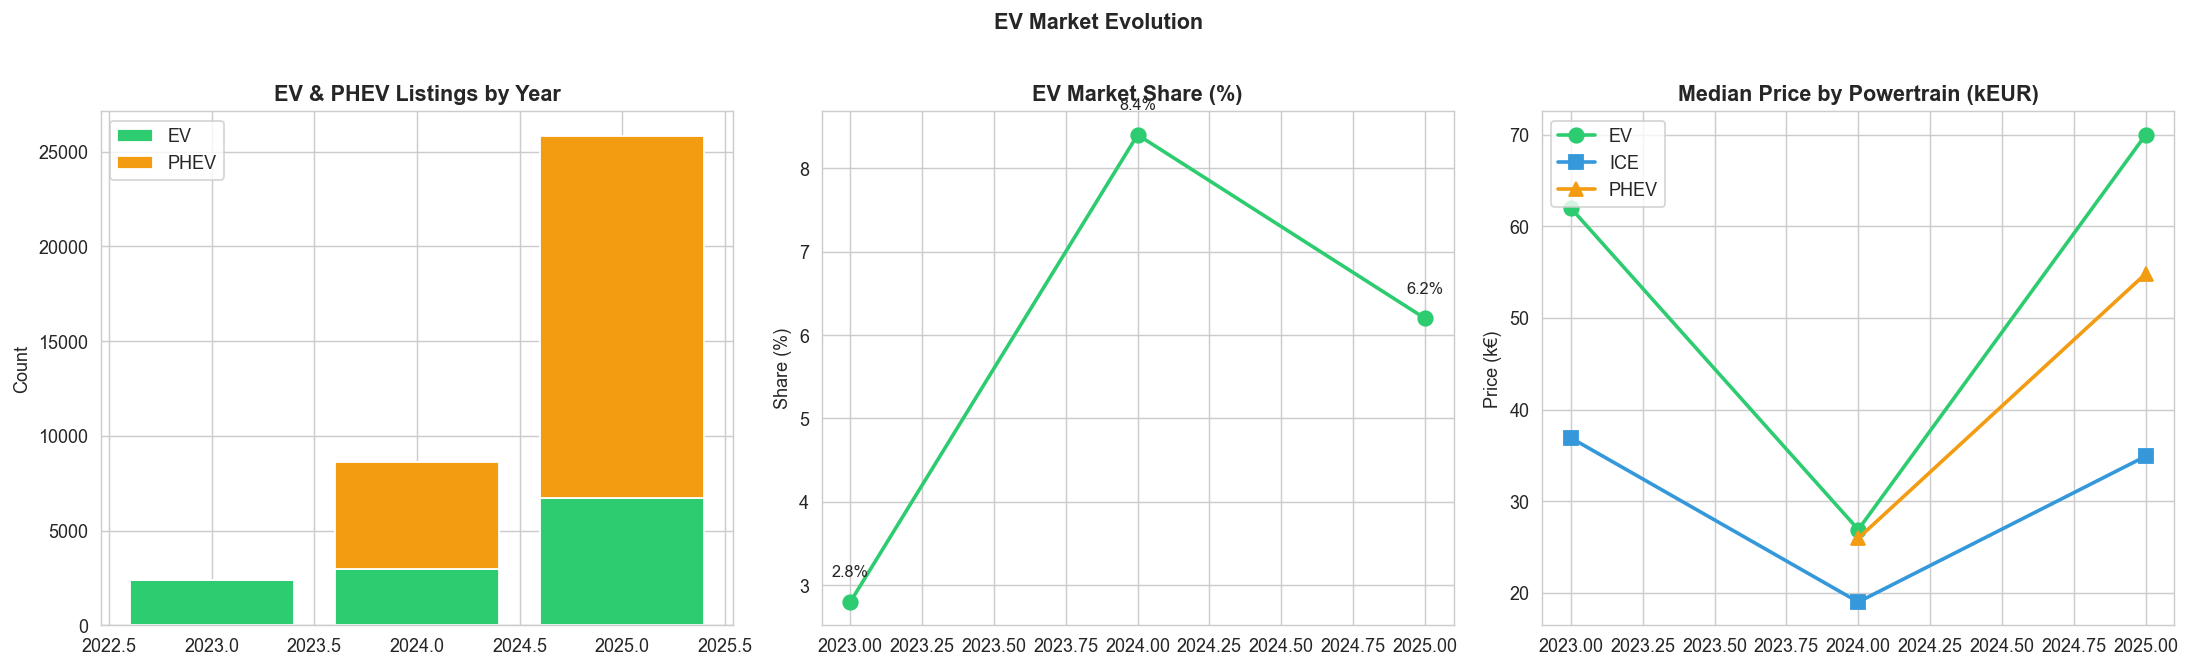

Saved: figures/05_01_ev_market_evolution.png


In [3]:
# Yearly stats
ev_yearly = []
for yr in sorted(df['data_year'].unique()):
    yr_df = df[df['data_year'] == yr]
    yr_ev = yr_df[yr_df['powertrain'] == 'EV']
    yr_phev = yr_df[yr_df['powertrain'] == 'PHEV']
    yr_ice = yr_df[yr_df['powertrain'] == 'ICE']
    ev_yearly.append({
        'Year': yr,
        'Total': len(yr_df),
        'EV_count': len(yr_ev),
        'PHEV_count': len(yr_phev),
        'ICE_count': len(yr_ice),
        'EV_share_%': round(len(yr_ev) / len(yr_df) * 100, 1),
        'EV_median_EUR': yr_ev['price_eur'].median() if len(yr_ev) > 0 else np.nan,
        'ICE_median_EUR': yr_ice['price_eur'].median() if len(yr_ice) > 0 else np.nan,
        'PHEV_median_EUR': yr_phev['price_eur'].median() if len(yr_phev) > 0 else np.nan,
    })

ev_yr_df = pd.DataFrame(ev_yearly)
print('EV Market Evolution:')
print(ev_yr_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Count
ax = axes[0]
ax.bar(ev_yr_df['Year'], ev_yr_df['EV_count'], color='#2ecc71', label='EV')
ax.bar(ev_yr_df['Year'], ev_yr_df['PHEV_count'], bottom=ev_yr_df['EV_count'],
       color='#f39c12', label='PHEV')
ax.set_title('EV & PHEV Listings by Year', fontweight='bold')
ax.set_ylabel('Count')
ax.legend()

# Share
ax = axes[1]
ax.plot(ev_yr_df['Year'], ev_yr_df['EV_share_%'], 'o-', color='#2ecc71',
        lw=2, markersize=8)
for _, row in ev_yr_df.iterrows():
    ax.text(row['Year'], row['EV_share_%'] + 0.3,
            f"{row['EV_share_%']:.1f}%", ha='center', fontsize=9)
ax.set_title('EV Market Share (%)', fontweight='bold')
ax.set_ylabel('Share (%)')

# Median price
ax = axes[2]
ax.plot(ev_yr_df['Year'], ev_yr_df['EV_median_EUR']/1000, 'o-',
        color='#2ecc71', lw=2, label='EV', markersize=8)
ax.plot(ev_yr_df['Year'], ev_yr_df['ICE_median_EUR']/1000, 's-',
        color='#3498db', lw=2, label='ICE', markersize=8)
ax.plot(ev_yr_df['Year'], ev_yr_df['PHEV_median_EUR']/1000, '^-',
        color='#f39c12', lw=2, label='PHEV', markersize=8)
ax.set_title('Median Price by Powertrain (kEUR)', fontweight='bold')
ax.set_ylabel('Price (k\u20ac)')
ax.legend()

plt.suptitle('EV Market Evolution', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '05_01_ev_market_evolution.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/05_01_ev_market_evolution.png')

## 3. EV Premium over ICE (%, Absolute, Cohen's d)

In [4]:
# Overall premium
ev_median  = df_ev['price_eur'].median()
ice_median = df_ice['price_eur'].median()
premium_pct = (ev_median - ice_median) / ice_median * 100
premium_abs = ev_median - ice_median

# Mann-Whitney U test
u_stat, u_pval = stats.mannwhitneyu(df_ev['price_eur'], df_ice['price_eur'],
                                     alternative='two-sided')

# Cohen's d
pooled_std = np.sqrt(
    ((len(df_ev)-1) * df_ev['price_eur'].std()**2 +
     (len(df_ice)-1) * df_ice['price_eur'].std()**2) /
    (len(df_ev) + len(df_ice) - 2)
)
cohens_d = (df_ev['price_eur'].mean() - df_ice['price_eur'].mean()) / pooled_std

print('EV Premium over ICE (Overall):')
print(f'  EV median:  \u20ac{ev_median:,.0f}')
print(f'  ICE median: \u20ac{ice_median:,.0f}')
print(f'  Premium:    +{premium_pct:.1f}% (\u20ac{premium_abs:,.0f})')
print(f'  Mann-Whitney U: U={u_stat:,.0f}, p={u_pval:.2e}')
print(f'  Cohen\'s d: {cohens_d:.3f} ({"large" if abs(cohens_d) > 0.8 else "medium" if abs(cohens_d) > 0.5 else "small"} effect)')

# Per-year premium
print('\nPer-Year EV Premium:')
year_premiums = []
for yr in sorted(df['data_year'].unique()):
    ev_m = df_ev[df_ev['data_year']==yr]['price_eur'].median()
    ice_m = df_ice[df_ice['data_year']==yr]['price_eur'].median()
    if pd.notna(ev_m) and pd.notna(ice_m) and ice_m > 0:
        prem = (ev_m - ice_m) / ice_m * 100
        n_ev_yr = len(df_ev[df_ev['data_year']==yr])
        # Cohen's d per year
        ev_yr = df_ev[df_ev['data_year']==yr]['price_eur']
        ice_yr = df_ice[df_ice['data_year']==yr]['price_eur']
        if len(ev_yr) > 1 and len(ice_yr) > 1:
            ps = np.sqrt(
                ((len(ev_yr)-1)*ev_yr.std()**2 + (len(ice_yr)-1)*ice_yr.std()**2) /
                (len(ev_yr)+len(ice_yr)-2)
            )
            d = (ev_yr.mean() - ice_yr.mean()) / ps if ps > 0 else 0
        else:
            d = np.nan
        year_premiums.append({'Year': yr, 'Premium_%': prem,
                              'Abs_EUR': ev_m - ice_m, 'N_ev': n_ev_yr,
                              'Cohens_d': d})
        print(f'  {yr}: +{prem:.1f}% (\u20ac{ev_m-ice_m:,.0f}), n_ev={n_ev_yr:,}, d={d:.3f}')

prem_df = pd.DataFrame(year_premiums)

EV Premium over ICE (Overall):
  EV median:  €56,990
  ICE median: €31,870
  Premium:    +78.8% (€25,120)
  Mann-Whitney U: U=1,489,754,604, p=0.00e+00
  Cohen's d: 0.324 (small effect)

Per-Year EV Premium:
  2023: +68.0% (€25,090), n_ev=2,372, d=0.312
  2024: +41.6% (€7,907), n_ev=2,954, d=-0.115
  2025: +100.5% (€35,090), n_ev=6,740, d=0.582


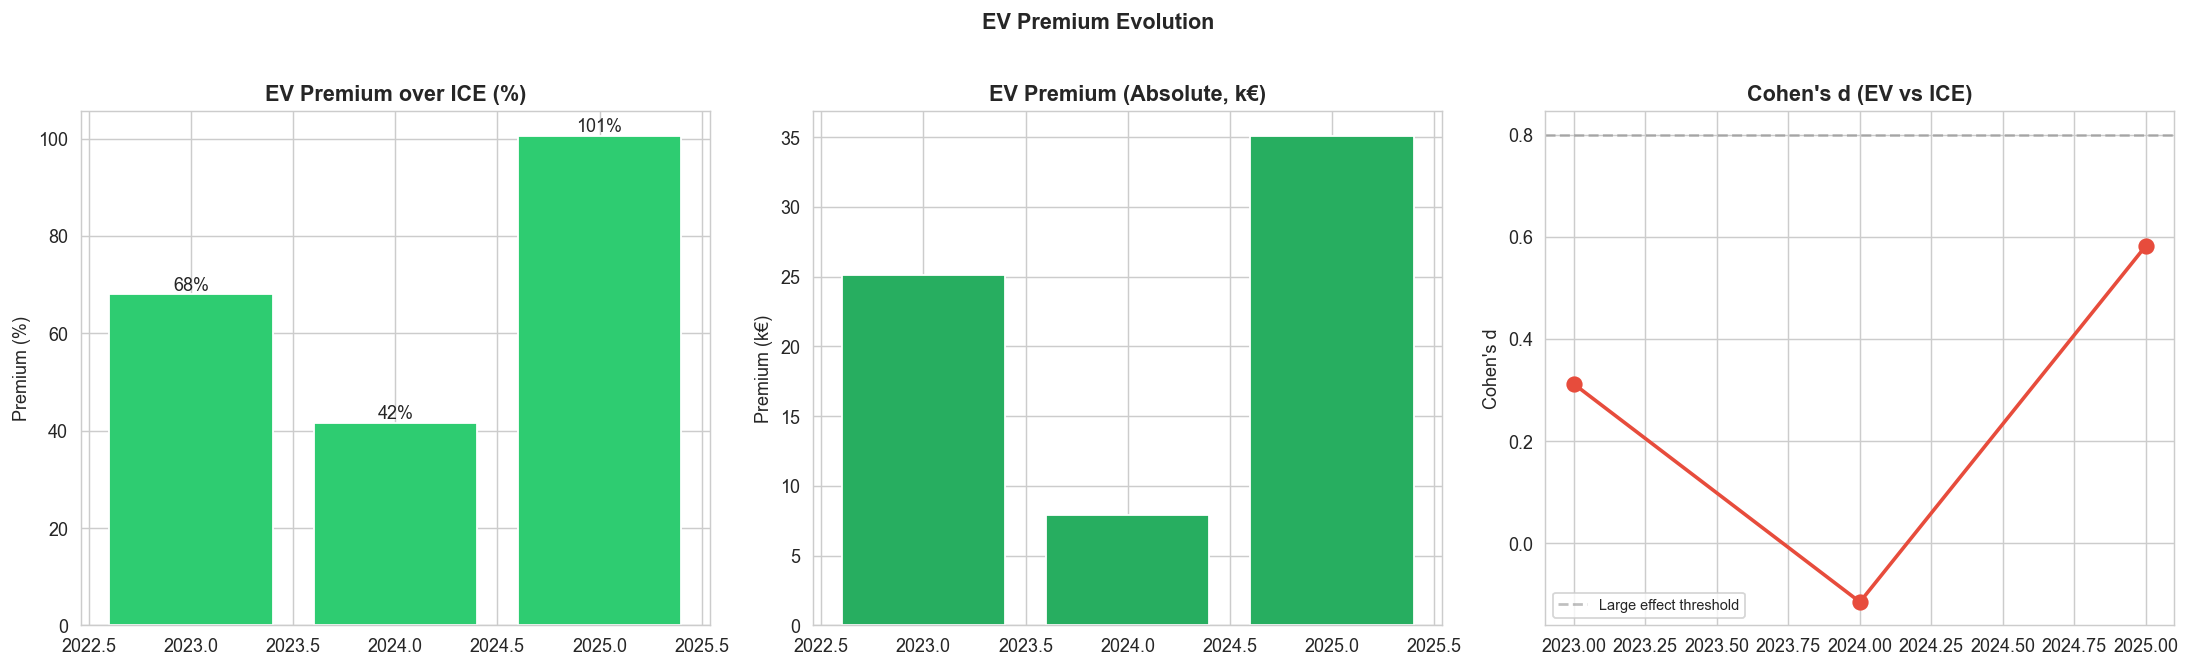

Saved: figures/05_02_ev_premium.png


In [5]:
# Visualize premium evolution
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
bars = ax.bar(prem_df['Year'], prem_df['Premium_%'], color='#2ecc71', edgecolor='white')
for bar, val in zip(bars, prem_df['Premium_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.0f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('EV Premium over ICE (%)', fontweight='bold')
ax.set_ylabel('Premium (%)')

ax = axes[1]
ax.bar(prem_df['Year'], prem_df['Abs_EUR']/1000, color='#27ae60', edgecolor='white')
ax.set_title('EV Premium (Absolute, k\u20ac)', fontweight='bold')
ax.set_ylabel('Premium (k\u20ac)')

ax = axes[2]
ax.plot(prem_df['Year'], prem_df['Cohens_d'], 'o-', color='#e74c3c',
        lw=2, markersize=8)
ax.axhline(0.8, ls='--', color='gray', alpha=0.5, label='Large effect threshold')
ax.set_title("Cohen's d (EV vs ICE)", fontweight='bold')
ax.set_ylabel("Cohen's d")
ax.legend(fontsize=8)

plt.suptitle('EV Premium Evolution', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '05_02_ev_premium.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/05_02_ev_premium.png')

## 4. EV vs ICE Depreciation Curves (Value Retention by Age)

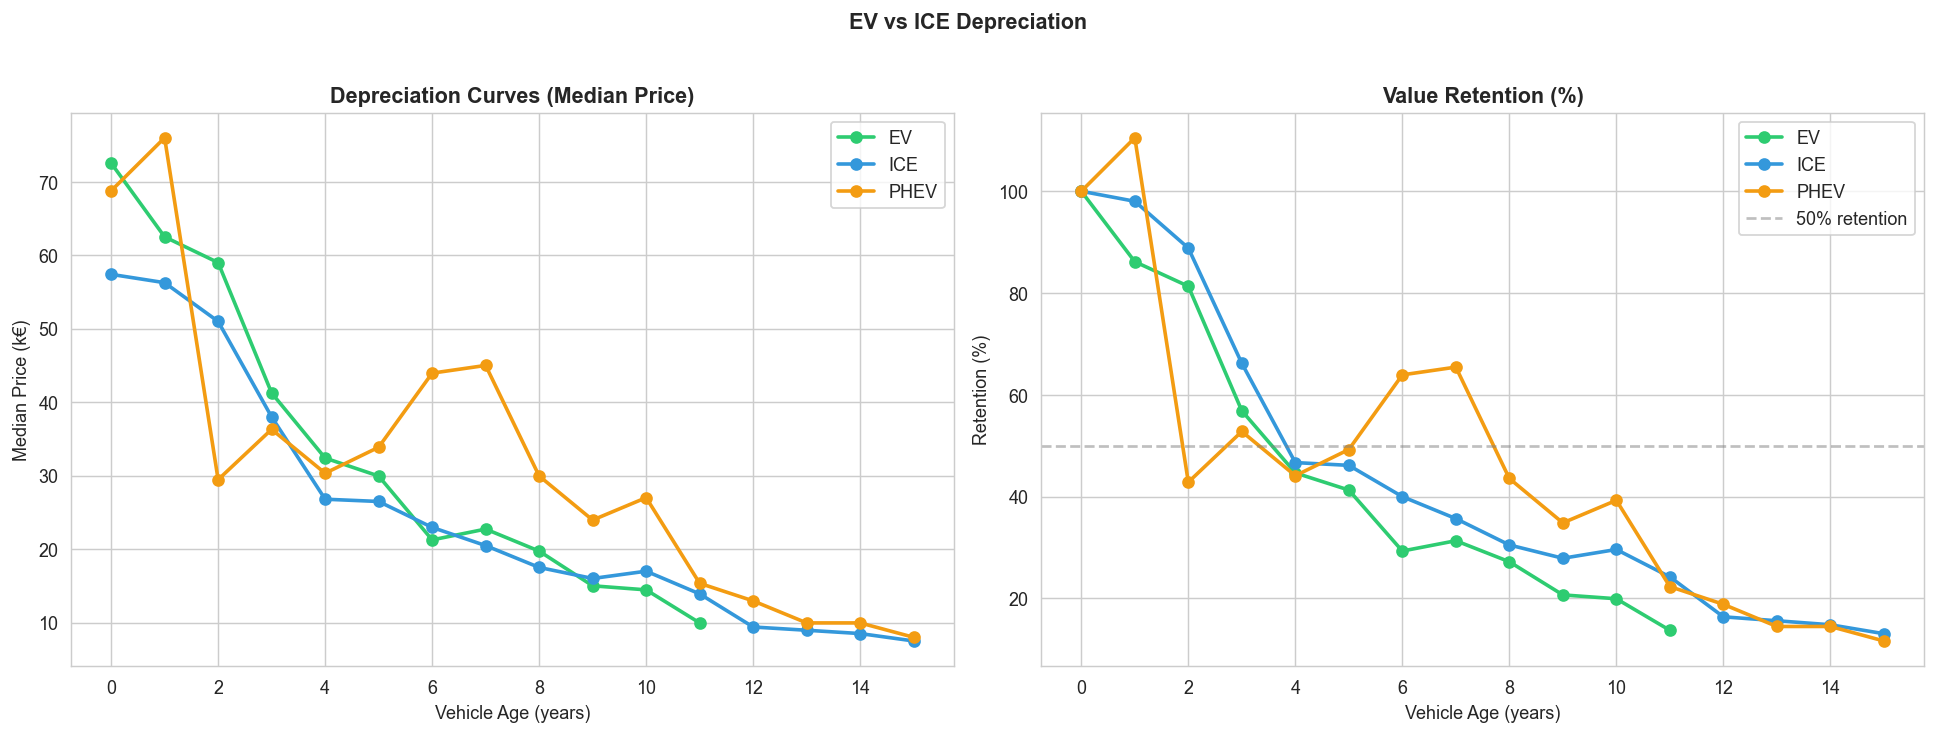

Saved: figures/05_03_depreciation_curves.png


In [6]:
# Median price by vehicle age for each powertrain
max_age = 15
age_range = range(0, max_age + 1)

depr_data = []
for pt, pt_df, color in [('EV', df_ev, '#2ecc71'), ('ICE', df_ice, '#3498db'),
                           ('PHEV', df_phev, '#f39c12')]:
    for age in age_range:
        subset = pt_df[pt_df['vehicle_age'] == age]
        if len(subset) >= 10:
            depr_data.append({
                'Powertrain': pt, 'Age': age,
                'Median_EUR': subset['price_eur'].median(),
                'N': len(subset)
            })

depr_df = pd.DataFrame(depr_data)

# Normalize to % of new price (age=0)
for pt in ['EV', 'ICE', 'PHEV']:
    base = depr_df[(depr_df['Powertrain'] == pt) & (depr_df['Age'] == 0)]['Median_EUR']
    if len(base) > 0:
        base_val = base.values[0]
        mask = depr_df['Powertrain'] == pt
        depr_df.loc[mask, 'Retention_%'] = depr_df.loc[mask, 'Median_EUR'] / base_val * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Absolute prices
ax = axes[0]
for pt, color in [('EV', '#2ecc71'), ('ICE', '#3498db'), ('PHEV', '#f39c12')]:
    sub = depr_df[depr_df['Powertrain'] == pt]
    ax.plot(sub['Age'], sub['Median_EUR']/1000, 'o-', color=color, label=pt, lw=2)
ax.set_title('Depreciation Curves (Median Price)', fontweight='bold')
ax.set_xlabel('Vehicle Age (years)')
ax.set_ylabel('Median Price (k\u20ac)')
ax.legend()

# Value retention %
ax = axes[1]
for pt, color in [('EV', '#2ecc71'), ('ICE', '#3498db'), ('PHEV', '#f39c12')]:
    sub = depr_df[depr_df['Powertrain'] == pt].dropna(subset=['Retention_%'])
    ax.plot(sub['Age'], sub['Retention_%'], 'o-', color=color, label=pt, lw=2)
ax.axhline(50, ls='--', color='gray', alpha=0.5, label='50% retention')
ax.set_title('Value Retention (%)', fontweight='bold')
ax.set_xlabel('Vehicle Age (years)')
ax.set_ylabel('Retention (%)')
ax.legend()

plt.suptitle('EV vs ICE Depreciation', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '05_03_depreciation_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/05_03_depreciation_curves.png')

## 5. EV-Only Model vs Full Model on EV Test Data

In [7]:
# Split EV data using same strategy
ev_features = [f for f in ml_features if f in df_ev.columns]
X_ev = df_ev[ev_features].copy()
y_ev = df_ev[target].values

X_ev_train, X_ev_test, y_ev_train, y_ev_test = train_test_split(
    X_ev, y_ev, test_size=0.2, random_state=RANDOM_STATE
)

# Impute
imp_ev = SimpleImputer(strategy='median')
X_ev_train_imp = imp_ev.fit_transform(X_ev_train)
X_ev_test_imp  = imp_ev.transform(X_ev_test)

# Train EV-only RF
rf_ev = RandomForestRegressor(
    n_estimators=500, min_samples_leaf=2, max_features=0.3,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_ev.fit(X_ev_train_imp, y_ev_train)
pred_ev_only = rf_ev.predict(X_ev_test_imp)

# Compare with full model on same EV test data
try:
    rf_full = joblib.load(MODELS_DIR / 'random_forest_best.pkl')
    prep = joblib.load(MODELS_DIR / 'preprocessor_ml.pkl')
    X_ev_test_full = prep['imputer'].transform(X_ev_test)
    pred_full_on_ev = rf_full.predict(X_ev_test_full)
    has_full = True
except:
    has_full = False
    print('Full model not found; training from scratch on full data...')
    # Recreate split
    if '_strat' not in df.columns:
        df['_strat'] = (df['country_code'].astype(str) + '_' +
                        df['make_grouped'].astype(str) + '_' +
                        df['data_year'].astype(str))
    strat_counts = df['_strat'].value_counts()
    rare = strat_counts[strat_counts < 5].index
    df.loc[df['_strat'].isin(rare), '_strat'] = 'rare_stratum'
    df_trainval, df_test_full = train_test_split(
        df, test_size=TEST_RATIO, random_state=RANDOM_STATE,
        stratify=df['_strat']
    )
    imp_full = SimpleImputer(strategy='median')
    X_tr_f = imp_full.fit_transform(df_trainval[ml_features])
    rf_full = RandomForestRegressor(
        n_estimators=500, min_samples_leaf=2, max_features=0.3,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    rf_full.fit(X_tr_f, df_trainval[target].values)
    X_ev_test_full = imp_full.transform(X_ev_test)
    pred_full_on_ev = rf_full.predict(X_ev_test_full)
    has_full = True

# Evaluate
print('\nEV-Only RF on EV test:')
rmse_evo = np.sqrt(mean_squared_error(y_ev_test, pred_ev_only))
r2_evo   = r2_score(y_ev_test, pred_ev_only)
mape_evo = mean_absolute_percentage_error(y_ev_test, pred_ev_only) * 100
print(f'  RMSE={rmse_evo:.4f}  R\u00b2={r2_evo:.4f}  MAPE={mape_evo:.2f}%')

if has_full:
    print('\nFull RF on EV test:')
    rmse_full = np.sqrt(mean_squared_error(y_ev_test, pred_full_on_ev))
    r2_full   = r2_score(y_ev_test, pred_full_on_ev)
    mape_full = mean_absolute_percentage_error(y_ev_test, pred_full_on_ev) * 100
    print(f'  RMSE={rmse_full:.4f}  R\u00b2={r2_full:.4f}  MAPE={mape_full:.2f}%')
    
    winner = 'EV-Only' if rmse_evo < rmse_full else 'Full'
    print(f'\n>>> {winner} model performs better on EV data.')


EV-Only RF on EV test:
  RMSE=0.3829  R²=0.7432  MAPE=1.89%

Full RF on EV test:
  RMSE=0.2948  R²=0.8478  MAPE=1.46%

>>> Full model performs better on EV data.


## 6. Battery Material Costs vs EV Prices

Spearman correlations and dual-axis charts for each of the 6 materials.

In [8]:
# Compute annual EV median price
ev_annual_price = df_ev.groupby('data_year')['price_eur'].median().reset_index()
ev_annual_price.columns = ['year', 'ev_median_eur']

# Merge material prices
mat_pivot = mat_annual.pivot_table(index='year', columns='material',
                                    values='price_usd_per_ton').reset_index()

# Filter to years in our data
analysis_years = sorted(df_ev['data_year'].unique())
ev_mat = ev_annual_price.merge(mat_pivot, on='year', how='inner')
ev_mat = ev_mat[ev_mat['year'].isin(analysis_years)].sort_values('year')

print('EV Median Price vs Material Costs (annual):')
print(ev_mat.to_string(index=False))

# Spearman correlations for each material
material_corrs = []
print('\nSpearman Correlations (EV median price vs material cost):')
print(f'{"Material":25s} {"r (sync)":>10s} {"p (sync)":>10s}')
print('-' * 50)
for material in MATERIALS:
    if material in ev_mat.columns:
        valid = ev_mat[['ev_median_eur', material]].dropna()
        if len(valid) >= 3:
            r, p = stats.spearmanr(valid['ev_median_eur'], valid[material])
            print(f'{material:25s} {r:10.3f} {p:10.3f}')
            mc = {'Material': material, 'r_sync': round(r, 3), 'p_sync': round(p, 3)}
            # Lag-1 correlation
            mat_lag = ev_mat[['year', material]].copy()
            mat_lag['year'] = mat_lag['year'] + 1
            mat_lag.columns = ['year', f'{material}_lag1']
            ev_lag = ev_annual_price.merge(mat_lag, on='year', how='inner')
            if len(ev_lag) >= 3:
                r_lag, p_lag = stats.spearmanr(ev_lag['ev_median_eur'],
                                               ev_lag[f'{material}_lag1'])
                mc['r_lag1'] = round(r_lag, 3)
                mc['p_lag1'] = round(p_lag, 3)
            else:
                mc['r_lag1'] = np.nan
                mc['p_lag1'] = np.nan
            material_corrs.append(mc)

corr_df = pd.DataFrame(material_corrs)
print('\nLag-1 correlations:')
print(corr_df.to_string(index=False))

EV Median Price vs Material Costs (annual):
 year  ev_median_eur  Cobalt  Dysprosium (Dy)  Graphite  Lithium  Neodymium (Nd)  Nickel
 2023        61990.1 27500.0         230000.0     775.0  27500.0         57500.0 19000.0
 2024        26897.0 21000.0         185000.0     625.0  12000.0         46500.0 16000.0
 2025        69990.0 23000.0         217500.0     660.0   8750.0         59500.0 20000.0

Spearman Correlations (EV median price vs material cost):
Material                    r (sync)   p (sync)
--------------------------------------------------
Lithium                       -0.500      0.667
Cobalt                         0.500      0.667
Nickel                         1.000      0.000
Graphite                       0.500      0.667
Neodymium (Nd)                 1.000      0.000
Dysprosium (Dy)                0.500      0.667

Lag-1 correlations:
       Material  r_sync  p_sync  r_lag1  p_lag1
        Lithium    -0.5   0.667     NaN     NaN
         Cobalt     0.5   0.667     N

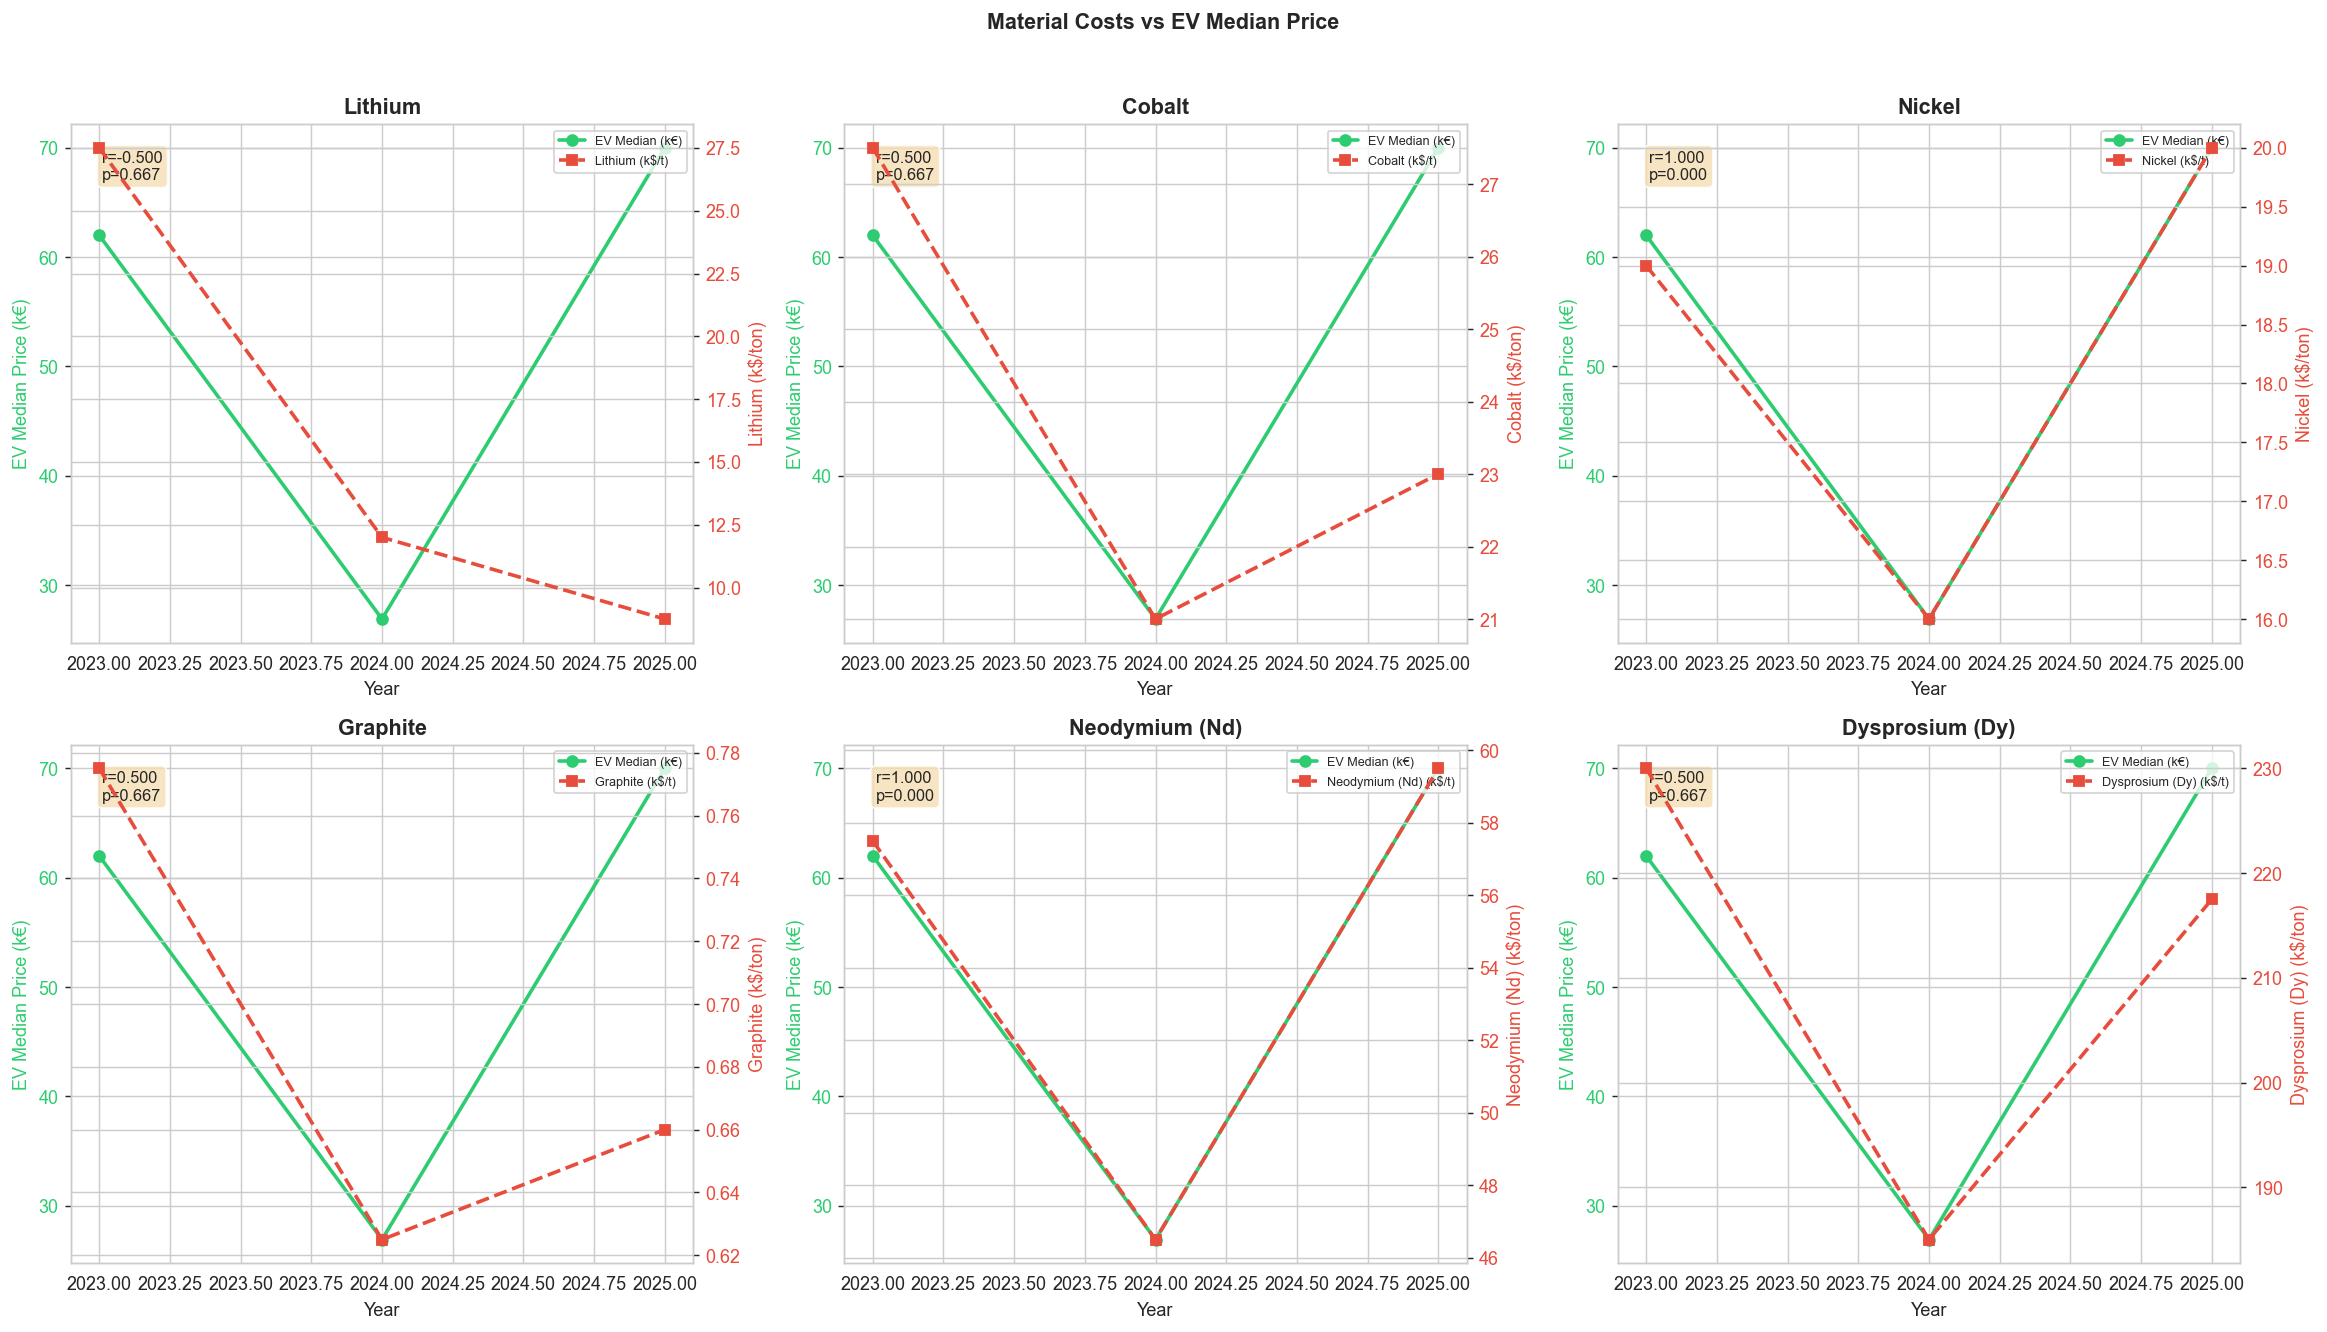

Saved: figures/05_04_material_vs_ev_price.png


In [9]:
# Dual-axis charts for each material
n_mat = len([m for m in MATERIALS if m in ev_mat.columns])
n_cols = 3
n_rows = (n_mat + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_mat == 1 else axes

plot_idx = 0
for material in MATERIALS:
    if material not in ev_mat.columns:
        continue
    ax1 = axes_flat[plot_idx]
    ax2 = ax1.twinx()

    ax1.plot(ev_mat['year'], ev_mat['ev_median_eur']/1000, 'o-',
             color='#2ecc71', lw=2, label='EV Median (k\u20ac)')
    ax2.plot(ev_mat['year'], ev_mat[material]/1000, 's--',
             color='#e74c3c', lw=2, label=f'{material} (k$/t)')

    ax1.set_xlabel('Year')
    ax1.set_ylabel('EV Median Price (k\u20ac)', color='#2ecc71')
    ax2.set_ylabel(f'{material} (k$/ton)', color='#e74c3c')
    ax1.tick_params(axis='y', labelcolor='#2ecc71')
    ax2.tick_params(axis='y', labelcolor='#e74c3c')

    # Add Spearman r
    mc = [c for c in material_corrs if c['Material'] == material]
    if mc:
        ax1.text(0.05, 0.95, f'r={mc[0]["r_sync"]:.3f}\np={mc[0]["p_sync"]:.3f}',
                 transform=ax1.transAxes, fontsize=9, va='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax1.set_title(material, fontweight='bold')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper right')
    plot_idx += 1

# Hide empty subplots
for i in range(plot_idx, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.suptitle('Material Costs vs EV Median Price', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '05_04_material_vs_ev_price.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/05_04_material_vs_ev_price.png')

## 7. Battery Cost Index Deep Analysis

Battery Cost Index:
 year  bci_raw  bci_norm  yoy_change_%
 2021 32775.00  0.806130           NaN
 2022 37400.00  1.000000     14.111365
 2023 21366.25  0.327901    -42.870989
 2024 13543.75  0.000000    -36.611478
 2025 13911.50  0.015415      2.715275

BCI vs EV median price: Spearman r=0.500, p=0.667


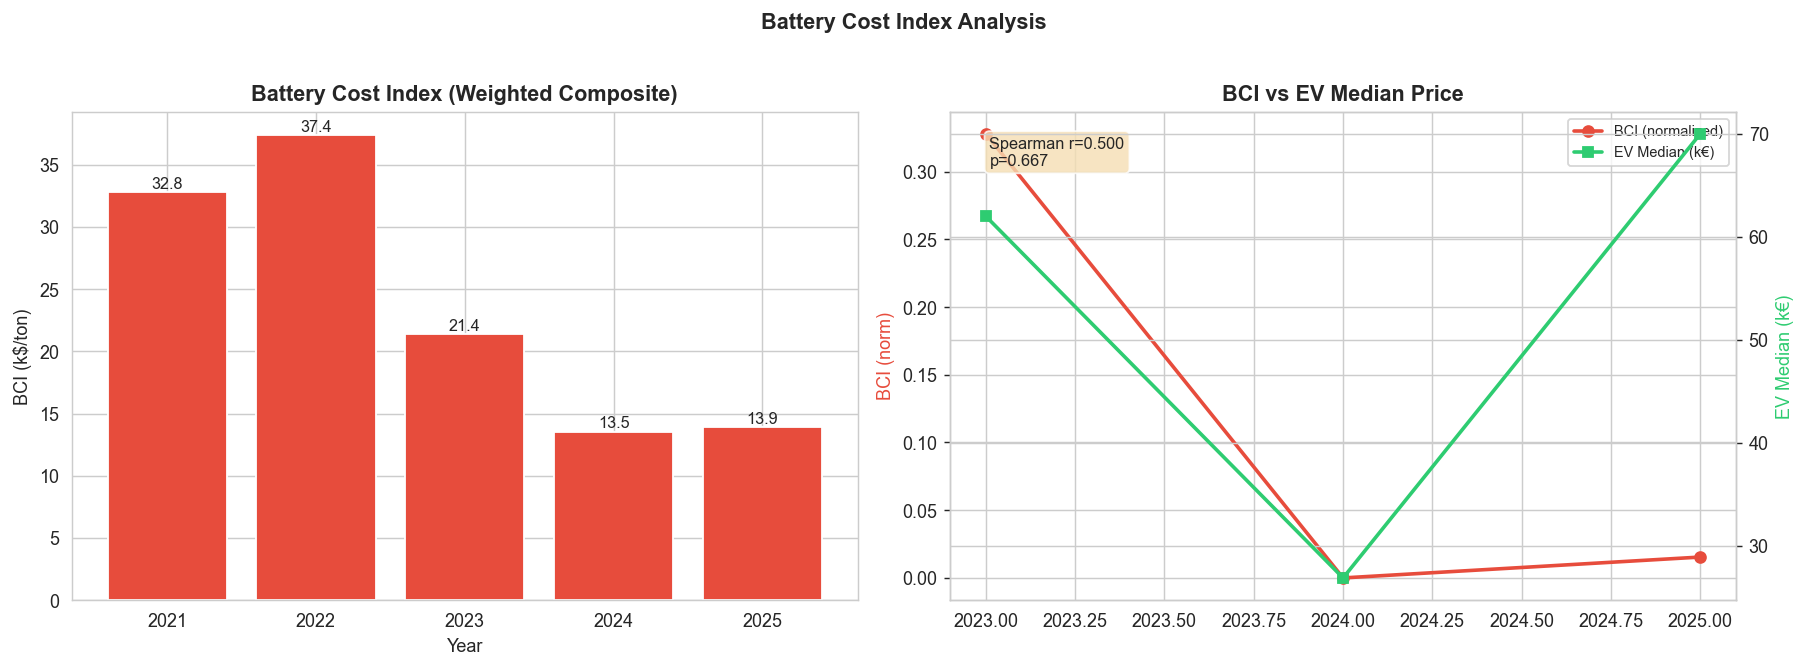

Saved: figures/05_05_bci_analysis.png


In [10]:
# Weighted composite Battery Cost Index
battery_weights = {'Lithium': 0.35, 'Cobalt': 0.25, 'Nickel': 0.25, 'Graphite': 0.15}

bci_data = []
for yr in sorted(mat_annual['year'].unique()):
    yr_mat = mat_annual[mat_annual['year'] == yr].set_index('material')['price_usd_per_ton']
    cost = sum(yr_mat.get(m, 0) * w for m, w in battery_weights.items())
    bci_data.append({'year': yr, 'bci_raw': cost})

bci = pd.DataFrame(bci_data)
bci['bci_norm'] = (bci['bci_raw'] - bci['bci_raw'].min()) / (bci['bci_raw'].max() - bci['bci_raw'].min())
bci['yoy_change_%'] = bci['bci_raw'].pct_change() * 100

print('Battery Cost Index:')
print(bci.to_string(index=False))

# BCI vs EV price correlation
bci_ev = bci.merge(ev_annual_price, on='year', how='inner')
bci_ev = bci_ev[bci_ev['year'].isin(analysis_years)]
if len(bci_ev) >= 3:
    r_bci, p_bci = stats.spearmanr(bci_ev['bci_norm'], bci_ev['ev_median_eur'])
    print(f'\nBCI vs EV median price: Spearman r={r_bci:.3f}, p={p_bci:.3f}')
else:
    r_bci, p_bci = np.nan, np.nan
    print('\nInsufficient overlapping years for BCI correlation.')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(bci['year'], bci['bci_raw']/1000, color='#e74c3c', edgecolor='white')
ax.set_title('Battery Cost Index (Weighted Composite)', fontweight='bold')
ax.set_ylabel('BCI (k$/ton)')
ax.set_xlabel('Year')
for _, row in bci.iterrows():
    ax.text(row['year'], row['bci_raw']/1000 + 0.3,
            f'{row["bci_raw"]/1000:.1f}', ha='center', fontsize=9)

ax = axes[1]
if len(bci_ev) >= 3:
    ax2 = ax.twinx()
    ax.plot(bci_ev['year'], bci_ev['bci_norm'], 'o-', color='#e74c3c',
            lw=2, label='BCI (normalized)')
    ax2.plot(bci_ev['year'], bci_ev['ev_median_eur']/1000, 's-', color='#2ecc71',
             lw=2, label='EV Median (k\u20ac)')
    ax.set_ylabel('BCI (norm)', color='#e74c3c')
    ax2.set_ylabel('EV Median (k\u20ac)', color='#2ecc71')
    ax.text(0.05, 0.95, f'Spearman r={r_bci:.3f}\np={p_bci:.3f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax.set_title('BCI vs EV Median Price', fontweight='bold')

plt.suptitle('Battery Cost Index Analysis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '05_05_bci_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/05_05_bci_analysis.png')

## 8. Brand-Level EV Analysis

Top 15 EV Brands by Listing Count:
  Porsche               n=2,447  median=€90,650
  Audi                  n=2,137  median=€72,990
  Mercedes-Benz         n=1,705  median=€58,700
  Bmw                   n=1,284  median=€50,394
  Byd                   n=689  median=€34,590
  Tesla                 n=675  median=€27,850
  Volkswagen            n=466  median=€57,975
  Smart                 n=291  median=€13,490
  Ford                  n=219  median=€49,900
  Renault               n=184  median=€11,675
  Hyundai               n=154  median=€37,335
  Alfa Romeo            n=146  median=€36,638
  Mg                    n=143  median=€21,880
  Opel                  n=141  median=€35,710
  Skoda                 n=141  median=€42,890

EV vs ICE Premium by Brand:
        Brand  EV_median  ICE_median  Premium_%  N_EV  N_ICE
         Ford    49900.0     15000.0 232.666667   219   6207
      Hyundai    37335.0     11450.0 226.069869   154   1151
      Porsche    90650.0     48000.0  88.854167  2447  

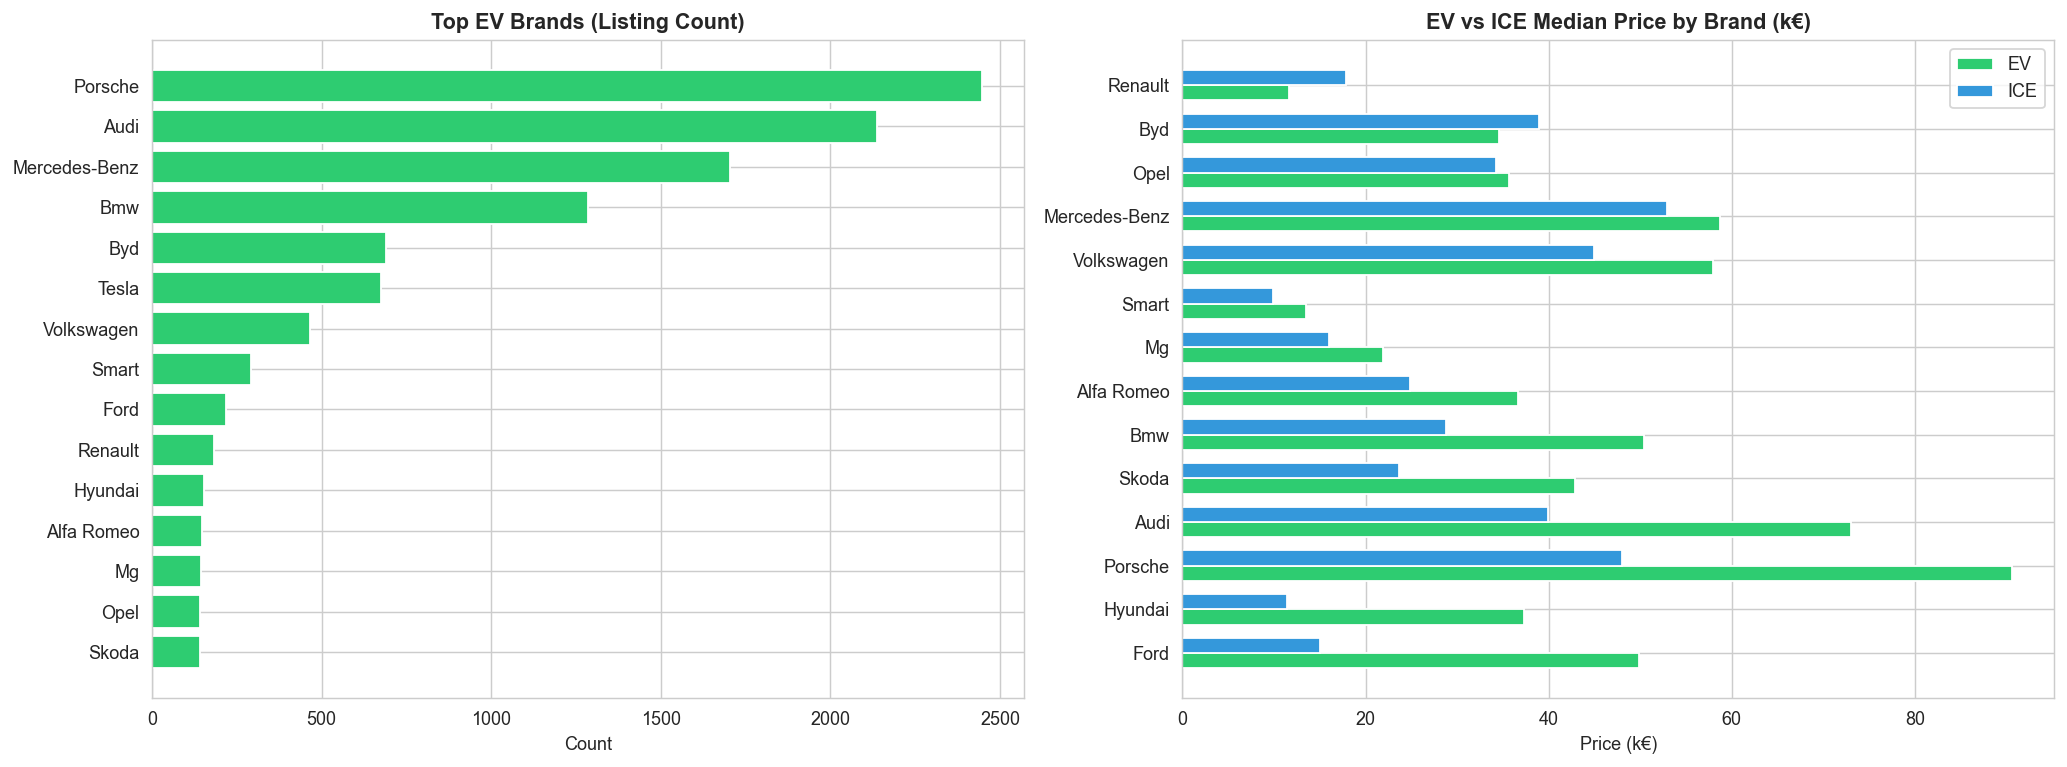

Saved: figures/05_06_ev_brands.png


In [11]:
# Top EV brands
ev_brand_counts = df_ev['make'].value_counts()
top_ev_brands = ev_brand_counts.head(15)

print('Top 15 EV Brands by Listing Count:')
for brand, cnt in top_ev_brands.items():
    med = df_ev[df_ev['make'] == brand]['price_eur'].median()
    print(f'  {brand:20s}  n={cnt:,}  median=\u20ac{med:,.0f}')

# EV vs ICE price by brand (for brands present in both)
brand_comp = []
for brand in top_ev_brands.index:
    ev_sub  = df_ev[df_ev['make'] == brand]['price_eur']
    ice_sub = df_ice[df_ice['make'] == brand]['price_eur']
    if len(ev_sub) >= 10 and len(ice_sub) >= 10:
        brand_comp.append({
            'Brand': brand,
            'EV_median': ev_sub.median(),
            'ICE_median': ice_sub.median(),
            'Premium_%': (ev_sub.median() - ice_sub.median()) / ice_sub.median() * 100,
            'N_EV': len(ev_sub), 'N_ICE': len(ice_sub)
        })

brand_df = pd.DataFrame(brand_comp).sort_values('Premium_%', ascending=False)
print('\nEV vs ICE Premium by Brand:')
print(brand_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.barh(top_ev_brands.index[::-1], top_ev_brands.values[::-1], color='#2ecc71')
ax.set_title('Top EV Brands (Listing Count)', fontweight='bold')
ax.set_xlabel('Count')

if len(brand_df) > 0:
    ax = axes[1]
    x = np.arange(len(brand_df))
    w = 0.35
    ax.barh(x - w/2, brand_df['EV_median']/1000, w, label='EV', color='#2ecc71')
    ax.barh(x + w/2, brand_df['ICE_median']/1000, w, label='ICE', color='#3498db')
    ax.set_yticks(x)
    ax.set_yticklabels(brand_df['Brand'])
    ax.set_title('EV vs ICE Median Price by Brand (k\u20ac)', fontweight='bold')
    ax.set_xlabel('Price (k\u20ac)')
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / '05_06_ev_brands.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/05_06_ev_brands.png')

## 9. Electric Range vs Price

EVs with electric range data: 4,652 / 12,066
Spearman r (range vs price): 0.441, p=4.10e-221


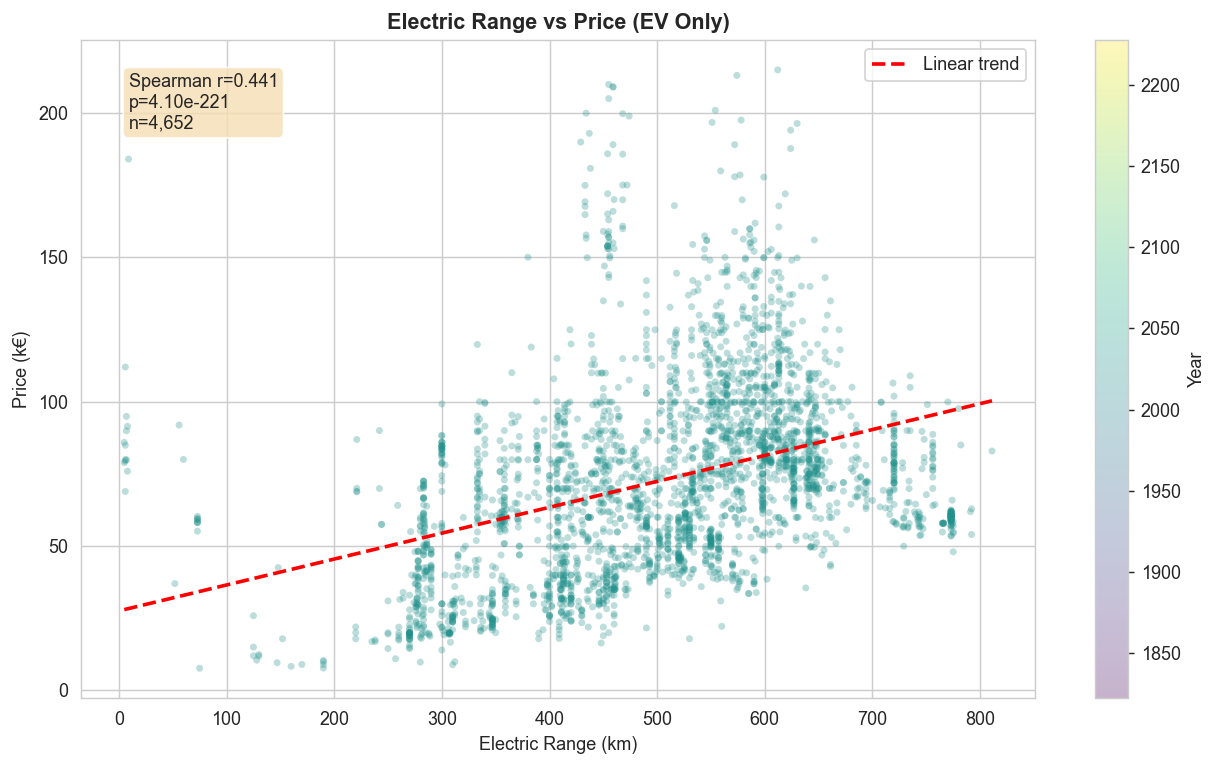

Saved: figures/05_07_range_vs_price.png


In [12]:
# Filter EVs with known electric range
df_ev['electric_range_km'] = pd.to_numeric(df_ev['electric_range_km'], errors='coerce')
ev_range = df_ev[df_ev['electric_range_km'] > 0].copy()
print(f'EVs with electric range data: {len(ev_range):,} / {len(df_ev):,}')

if len(ev_range) >= 20:
    r_range, p_range = stats.spearmanr(ev_range['electric_range_km'],
                                        ev_range['price_eur'])
    print(f'Spearman r (range vs price): {r_range:.3f}, p={p_range:.2e}')

    fig, ax = plt.subplots(figsize=(10, 6))
    # Subsample for plot clarity
    plot_df = ev_range.sample(n=min(3000, len(ev_range)), random_state=42)
    scatter = ax.scatter(plot_df['electric_range_km'], plot_df['price_eur']/1000,
                         alpha=0.3, s=15, c=plot_df['data_year'],
                         cmap='viridis', edgecolors='none')
    plt.colorbar(scatter, label='Year')

    # Trend line
    z = np.polyfit(ev_range['electric_range_km'], ev_range['price_eur']/1000, 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(ev_range['electric_range_km'].min(),
                          ev_range['electric_range_km'].max(), 100)
    ax.plot(x_line, p_fit(x_line), 'r--', lw=2, label='Linear trend')

    ax.text(0.05, 0.95, f'Spearman r={r_range:.3f}\np={p_range:.2e}\nn={len(ev_range):,}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.set_xlabel('Electric Range (km)')
    ax.set_ylabel('Price (k\u20ac)')
    ax.set_title('Electric Range vs Price (EV Only)', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / '05_07_range_vs_price.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: figures/05_07_range_vs_price.png')
else:
    r_range, p_range = np.nan, np.nan
    print('Insufficient data for range-price analysis.')

## 10. Summary of Key EV Findings & Save Results

In [13]:
ev_analysis_results = {
    # Market overview
    'ev_count': int(len(df_ev)),
    'phev_count': int(len(df_phev)),
    'ice_count': int(len(df_ice)),
    'ev_market_share_pct': round(len(df_ev) / len(df) * 100, 1),
    'phev_market_share_pct': round(len(df_phev) / len(df) * 100, 1),
    
    # Premium
    'ev_premium_pct': round(premium_pct, 1),
    'ev_premium_abs_eur': round(premium_abs),
    'cohens_d': round(cohens_d, 3),
    'mann_whitney_u': float(u_stat),
    'mann_whitney_p': float(u_pval),
    
    # BCI
    'bci_ev_spearman_r': round(float(r_bci), 3) if not np.isnan(r_bci) else None,
    'bci_ev_spearman_p': round(float(p_bci), 3) if not np.isnan(p_bci) else None,
    
    # Range
    'range_price_spearman_r': round(float(r_range), 3) if not np.isnan(r_range) else None,
    'range_price_spearman_p': float(p_range) if not np.isnan(p_range) else None,
    'n_ev_with_range': int(len(ev_range)) if 'ev_range' in dir() else 0,
    
    # Year premiums
    'year_premiums': year_premiums,
    
    # Material correlations
    'material_correlations': material_corrs,
    
    # EV-only model performance
    'ev_only_model_rmse': round(rmse_evo, 4),
    'ev_only_model_r2': round(r2_evo, 4),
}

with open(DATA_PROC / 'ev_analysis_results.json', 'w') as f:
    json.dump(ev_analysis_results, f, indent=2, default=str)
print(f'Saved: ev_analysis_results.json')

print('\n' + '=' * 70)
print('KEY EV FINDINGS SUMMARY')
print('=' * 70)
print(f'''
Market Presence:
  {len(df_ev):,} EVs ({len(df_ev)/len(df)*100:.1f}% of dataset)
  {len(df_phev):,} PHEVs ({len(df_phev)/len(df)*100:.1f}%)

EV Price Premium:
  Overall: +{premium_pct:.1f}% over ICE (\u20ac{premium_abs:,.0f})
  Cohen's d: {cohens_d:.3f} ({'large' if abs(cohens_d) > 0.8 else 'medium'} effect)

Battery Cost Index:
  BCI vs EV price: Spearman r = {r_bci:.3f}
  Correlation is {'weak' if abs(r_bci) < 0.4 else 'moderate' if abs(r_bci) < 0.7 else 'strong'}
  (limited by n={len(bci_ev)} annual observations)

Electric Range:
  Range vs price: Spearman r = {r_range:.3f}
  Longer range EVs command higher prices

EV-Only Model:
  RMSE={rmse_evo:.4f}, R\u00b2={r2_evo:.4f}
''')

print('=' * 70)
print('NOTEBOOK 05 COMPLETE')
print('=' * 70)

Saved: ev_analysis_results.json

KEY EV FINDINGS SUMMARY

Market Presence:
  12,066 EVs (5.3% of dataset)
  24,732 PHEVs (10.8%)

EV Price Premium:
  Overall: +78.8% over ICE (€25,120)
  Cohen's d: 0.324 (medium effect)

Battery Cost Index:
  BCI vs EV price: Spearman r = 0.500
  Correlation is moderate
  (limited by n=3 annual observations)

Electric Range:
  Range vs price: Spearman r = 0.441
  Longer range EVs command higher prices

EV-Only Model:
  RMSE=0.3829, R²=0.7432

NOTEBOOK 05 COMPLETE
